In [284]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, Layer, Input
from tensorflow.keras.models import Model, load_model
from tf_explain.core.integrated_gradients import IntegratedGradients

from transformers import TFBertModel, BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from lime.lime_tabular import LimeTabularExplainer
import shap
from collections import defaultdict
import itertools
import logging
import time
import re
import pickle

In [229]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [230]:
# load and preprocess data: cali housing

cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns if col != 'Median_House_Value']
X = cali_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# preprocessing

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [267]:
print(X_train.head())

   Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  Population  Households  \
0         3.4471          31       1534           292         716         288   
1         6.0238          23       1650           403         541         336   
2         5.0772          17       3912           737        2693         746   
3         5.2729          13        833           130         405         127   
4         3.5652          14       2421           489        1000         354   

   Latitude  Longitude  Distance_to_coast  Distance_to_LA  \
0     38.44    -122.86       21208.492760   639663.759445   
1     37.89    -122.49        6108.410600   572685.177355   
2     37.27    -121.80       33281.881376   480798.748124   
3     36.90    -121.68       12564.912440   443887.794112   
4     39.32    -120.17      183285.934321   610368.465504   

   Distance_to_SanDiego  Distance_to_SanJose  Distance_to_SanFrancisco  
0         818622.418614        149279.148511              83015.812048  


In [231]:
# make the data into strings
X_train_texts = X_train_scaled.astype(str).apply(' '.join, axis=1).tolist()
X_test_texts = X_test_scaled.astype(str).apply(' '.join, axis=1).tolist()

In [232]:
# Load the pre-trained BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [281]:
# Function to concatenate column names and values
def concatenate_columns_with_names(df):
    concatenated = df.apply(lambda row: ' '.join([f"{col} {val}" for col, val in row.items()]), axis=1)
    return concatenated.tolist()
# Concatenate column names and values for each instance
X_train_texts_with_names = concatenate_columns_with_names(X_train_scaled)
X_test_texts_with_names = concatenate_columns_with_names(X_test_scaled)

In [282]:
# Tokenize and encode inputs
max_length = 230  # Define maximum sequence length
train_encodings = tokenizer(X_train_texts_with_names, truncation=True, padding=True, max_length=max_length, return_tensors='tf')
test_encodings = tokenizer(X_test_texts_with_names, truncation=True, padding=True, max_length=max_length, return_tensors='tf')

In [290]:
# Define BERT inputs and outputs
input_ids = train_encodings['input_ids']
attention_mask = train_encodings['attention_mask']

In [ ]:

# Extract BERT output
bert_output = bert_model(input_ids, attention_mask=attention_mask)[0]  # Extract BERT output
bert_output = tf.keras.layers.GlobalAveragePooling1D()(bert_output)  # Pooling over sequence length


In [ ]:
# MLP layers
dense_size = 128
dropout_rate = 0.1

dense1 = Dense(dense_size, activation='relu')(bert_output)
dropout1 = Dropout(dropout_rate)(dense1)
dense2 = Dense(dense_size, activation='relu')(dropout1)
dropout2 = Dropout(dropout_rate)(dense2)
output = Dense(1, activation='linear')(dropout2)

# Combine BERT and MLP into a single model
model = Model(inputs=[input_ids, attention_mask], outputs=output)

# Freeze BERT layers during initial training
bert_model.trainable = False

# Compile model
model.compile(optimizer='adam', loss='mse')


In [233]:
class MLP(tf.keras.Model):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.1):
        super(MLP, self).__init__()
        self.dense1 = Dense(hidden_dim, activation='relu')
        self.dropout1 = Dropout(dropout_rate)
        self.dense2 = Dense(hidden_dim, activation='relu')
        self.dropout2 = Dropout(dropout_rate)
        self.dense3 = Dense(1, activation='linear')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        x = self.dense3(x)
        return x

In [234]:
class DropConnectDense(tf.keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.1, **kwargs):
        super(DropConnectDense, self).__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate
        self.dense = Dense(units)

    def build(self, input_shape):
        self.kernel = self.add_weight("kernel", shape=[input_shape[-1], self.units])
        self.bias = self.add_weight("bias", shape=[self.units])

    def call(self, inputs, training=False):
        if training:
            weights = self.dense.kernel * tf.keras.backend.random_binomial(
                shape=self.dense.kernel.shape, p=1 - self.dropout_rate)
            output = tf.keras.backend.dot(inputs, weights)
            if self.dense.use_bias:
                output = tf.keras.backend.bias_add(output, self.dense.bias)
            return self.dense.activation(output)
        else:
            return self.dense(inputs)

class MLPDropConnect(tf.keras.Model):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.1):
        super(MLPDropConnect, self).__init__()
        self.dense1 = DropConnectDense(hidden_dim, dropout_rate)
        self.dense2 = DropConnectDense(hidden_dim, dropout_rate)
        self.dense3 = Dense(1, activation='linear')
    
    def call(self, inputs, training=False):
        x = self.dense1(inputs, training=training)
        x = self.dense2(x, training=training)
        x = self.dense3(x)
        return x

In [235]:
def predict_with_uncertainty(model, inputs, num_samples=10):
    inputs = tf.expand_dims(inputs, axis=0)  # Add batch dimension
    predictions = []
    lime_explanations = []
    shap_explanations = []
    for _ in range(num_samples):
        prediction = model(inputs, training=True)
        predictions.append(prediction)
        lime_explanation = explain_lime(model, inputs[0], X_train_scaled, num_features)
        shap_explanation = explain_shap(model, inputs[0], X_train_scaled)
        lime_explanations.append(lime_explanation)
        shap_explanations.append(shap_explanation)
    predictions = tf.stack(predictions, axis=0)
    prediction_mean = tf.reduce_mean(predictions, axis=0)
    prediction_std = tf.math.reduce_std(predictions, axis=0)
    return prediction_mean.numpy(), prediction_std.numpy(), lime_explanations, shap_explanations

In [236]:
def explain_lime(model, instance, data, num_features):
    explainer = LimeTabularExplainer(
        training_data=np.array(data),
        feature_names=[f'feature_{i}' for i in range(data.shape[1])],
        mode='regression'
    )
    explanation = explainer.explain_instance(instance.numpy(), model.predict, num_features=num_features)
    return explanation

In [237]:
def explain_shap(model, instance, data):
    explainer = shap.KernelExplainer(model.predict, data)
    shap_values = explainer.shap_values(instance.numpy())
    return shap_values

In [238]:
class ModelWithUncertainty(Model):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.1, method='mc_dropout'):
        super(ModelWithUncertainty, self).__init__()
        self.method = method
        if method == 'mc_dropout':
            self.model = MLP(input_dim, hidden_dim, dropout_rate)
        elif method == 'dropconnect':
            self.model = MLPDropConnect(input_dim, hidden_dim, dropout_rate)
        else:
            raise ValueError("Method should be 'mc_dropout' or 'dropconnect'")
    
    def call(self, inputs, training=False):
        return self.model(inputs, training=training)
    
    def predict_with_uncertainty(self, inputs, num_samples):
        return predict_with_uncertainty(self.model, inputs, num_samples)

    def explain_lime(self, instance, data, num_features):
        return explain_lime(self.model, instance, data, num_features=num_features)

    def explain_shap(self, instance, data):
        return explain_shap(self.model, instance, data)

In [246]:
# set values

dense_size = 300
dropout_rate = 0.1
num_samples = 10
num_features = 13
explain_instance = 3

In [240]:
model = ModelWithUncertainty(input_dim=num_features, hidden_dim=dense_size, method='mc_dropout')
model.compile(optimizer='adam', loss='mse')

In [241]:
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=200, 
    validation_split=0.2
)

Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 54588796928.0000 - val_loss: 30395748352.0000
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20674764800.0000 - val_loss: 8750361600.0000
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8712202240.0000 - val_loss: 7112193536.0000
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7135682560.0000 - val_loss: 6253727744.0000
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6544606720.0000 - val_loss: 5709728768.0000
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5799184384.0000 - val_loss: 5262514176.0000
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5478008832.0000 - val_loss: 4899921920.0000
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4970824704.0000 - val_loss: 4633865728.0000
Epoch 9/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4788253184.0000 - val_loss: 4424366592.0000
Epoch 10/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [242]:
instance = X_test_scaled.iloc[:explain_instance].values

In [247]:
explanations_lime_3=[]
explanations_shap_3=[]
mean_3=[]
std_3=[]
for i in range(explain_instance):
    mean, std, explanation_l, explanation_s = model.predict_with_uncertainty(instance[i], num_samples)
    explanations_lime_3.append(explanation_l)
    explanations_shap_3.append(explanation_s)
    mean_3.append(mean)
    std_3.append(std)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step


2024-06-25 13:34:05,988 - WARNING - Using 16512 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


2024-06-25 13:34:08,743 - INFO - num_full_subsets = 3
2024-06-25 13:34:08,743 - INFO - remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
2024-06-25 13:34:08,744 - INFO - num_paired_subset_sizes = 6
2024-06-25 13:34:08,928 - INFO - weight_left = 0.32084025993652715


1070184/1070184 ━━━━━━━━━━━━━━━━━━━━ 1531s 1ms/step


...

2024-06-25 17:22:04,962 - WARNING - Using 16512 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


2024-06-25 17:22:07,592 - INFO - num_full_subsets = 3
2024-06-25 17:22:07,593 - INFO - remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
2024-06-25 17:22:07,593 - INFO - num_paired_subset_sizes = 6
2024-06-25 17:22:07,757 - INFO - weight_left = 0.32084025993652715


1070184/1070184 ━━━━━━━━━━━━━━━━━━━━ 315s 294us/step


2024-06-25 17:29:17,901 - INFO - phi = array([ -6261.05078283,  -4420.69583378,  39471.30693606,  -8907.348025  ,
       -71975.38000601,  36142.02308148,  54067.95471717, -60456.78297491,
        -8282.02392735,  50961.12823945,  24259.02553264, -20860.61011048,
       -38075.90276503])


In [248]:
lime_ins1 = explanations_lime_3[0]

In [256]:
lime_ins1_exp1 = lime_ins1[0]

In [265]:
lime_explanation = lime_ins1

In [270]:
def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
def sort_features_by_name(explanation):
    # Extract the features and their weights
    features_weights = explanation.as_list()
    # Sort the features based on their names
    sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
    return sorted_features_weights
for i, explanation in enumerate(lime_ins1):
    print(f'Explanation for sample {i+1}:')
    sorted_features = sort_features_by_name(explanation)
    for feature, weight in sorted_features:
        print(f'Feature: {feature}, Weight: {weight}')
    print("Predicted value:", explanation.predicted_value)
    print()

Explanation for sample 1:
Feature: feature_0 > 0.46, Weight: 77539.07568641129
Feature: feature_1 <= -0.85, Weight: -2966.4352185754833
Feature: feature_2 > 0.24, Weight: 105803.57090605304
Feature: -0.24 < feature_3 <= 0.26, Weight: -2149.752163393452
Feature: feature_4 > 0.27, Weight: -111325.55804619254
Feature: -0.23 < feature_5 <= 0.28, Weight: -9303.269830498075
Feature: -0.64 < feature_6 <= 0.97, Weight: -45733.99538714973
Feature: feature_7 <= -1.11, Weight: 140101.59448525697
Feature: -0.64 < feature_8 <= -0.41, Weight: 12780.640510995265
Feature: -0.39 < feature_9 <= 1.04, Weight: -46875.41620740118
Feature: -0.63 < feature_10 <= 1.06, Weight: -22412.74444368874
Feature: feature_11 <= -1.09, Weight: 50201.62931460815
Feature: feature_12 <= -1.08, Weight: 83880.36746362086
Predicted value: 296241.4

Explanation for sample 2:
Feature: feature_0 > 0.46, Weight: 76057.5692669841
Feature: feature_1 <= -0.85, Weight: -8240.21920190773
Feature: feature_2 > 0.24, Weight: 103512.34710

In [273]:
def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
def sort_features_by_name(explanation):
    # Extract the features and their weights
    features_weights = explanation.as_list()
    # Sort the features based on their names
    sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
    return sorted_features_weights


feature_weights = defaultdict(list)

for explanation in lime_ins1:
    sorted_features = sort_features_by_name(explanation)
    for feature, weight in sorted_features:
        feature_weights[feature].append(weight)

feature_stats = {}
for feature, weights in feature_weights.items():
    mean_weight = np.mean(weights)
    std_weight = np.std(weights)
    feature_stats[feature] = {'mean': mean_weight, 'std': std_weight}

print(feature_stats)

{'feature_0 > 0.46': {'mean': 79137.25809319108, 'std': 6054.901239142601}, 'feature_1 <= -0.85': {'mean': -7353.96469424683, 'std': 2818.5425228251625}, 'feature_2 > 0.24': {'mean': 101489.42311052166, 'std': 4356.517874065062}, '-0.24 < feature_3 <= 0.26': {'mean': -1967.5456862971337, 'std': 2844.893039009377}, 'feature_4 > 0.27': {'mean': -112537.45738831311, 'std': 2403.6988643209056}, '-0.23 < feature_5 <= 0.28': {'mean': -12902.292225916193, 'std': 4014.7313573349866}, '-0.64 < feature_6 <= 0.97': {'mean': -44281.49050838731, 'std': 4105.87175297169}, 'feature_7 <= -1.11': {'mean': 145752.46816763945, 'std': 6527.420305111705}, '-0.64 < feature_8 <= -0.41': {'mean': 18148.123058189187, 'std': 4425.585522761832}, '-0.39 < feature_9 <= 1.04': {'mean': -49174.879226254816, 'std': 2230.609135579978}, '-0.63 < feature_10 <= 1.06': {'mean': -19612.399396951372, 'std': 2545.192905039164}, 'feature_11 <= -1.09': {'mean': 50436.79026611372, 'std': 3752.269065522987}, 'feature_12 <= -1.08

In [278]:
feature_to_column = {f'feature_{i}': col for i, col in enumerate(X_test.columns)}
# Substitute feature_i with actual column names in feature_stats
def replace_features(text, feature_to_column):
    pattern = re.compile(r'feature_\d+')
    matches = pattern.findall(text)
    for match in matches:
        text = text.replace(match, feature_to_column.get(match, match))
    return text

# Substitute feature_i with actual column names in feature_stats
updated_feature_stats = {}
for feature, stats in feature_stats.items():
    new_feature = replace_features(feature, feature_to_column)
    updated_feature_stats[new_feature] = stats

# Print the updated feature_stats
print(updated_feature_stats)

{'Median_Income > 0.46': {'mean': 79137.25809319108, 'std': 6054.901239142601}, 'Median_Age <= -0.85': {'mean': -7353.96469424683, 'std': 2818.5425228251625}, 'Tot_Rooms > 0.24': {'mean': 101489.42311052166, 'std': 4356.517874065062}, '-0.24 < Tot_Bedrooms <= 0.26': {'mean': -1967.5456862971337, 'std': 2844.893039009377}, 'Population > 0.27': {'mean': -112537.45738831311, 'std': 2403.6988643209056}, '-0.23 < Households <= 0.28': {'mean': -12902.292225916193, 'std': 4014.7313573349866}, '-0.64 < Latitude <= 0.97': {'mean': -44281.49050838731, 'std': 4105.87175297169}, 'Longitude <= -1.11': {'mean': 145752.46816763945, 'std': 6527.420305111705}, '-0.64 < Distance_to_coast <= -0.41': {'mean': 18148.123058189187, 'std': 4425.585522761832}, '-0.39 < Distance_to_LA <= 1.04': {'mean': -49174.879226254816, 'std': 2230.609135579978}, '-0.63 < Distance_to_SanDiego <= 1.06': {'mean': -19612.399396951372, 'std': 2545.192905039164}, 'Distance_to_SanJose <= -1.09': {'mean': 50436.79026611372, 'std':

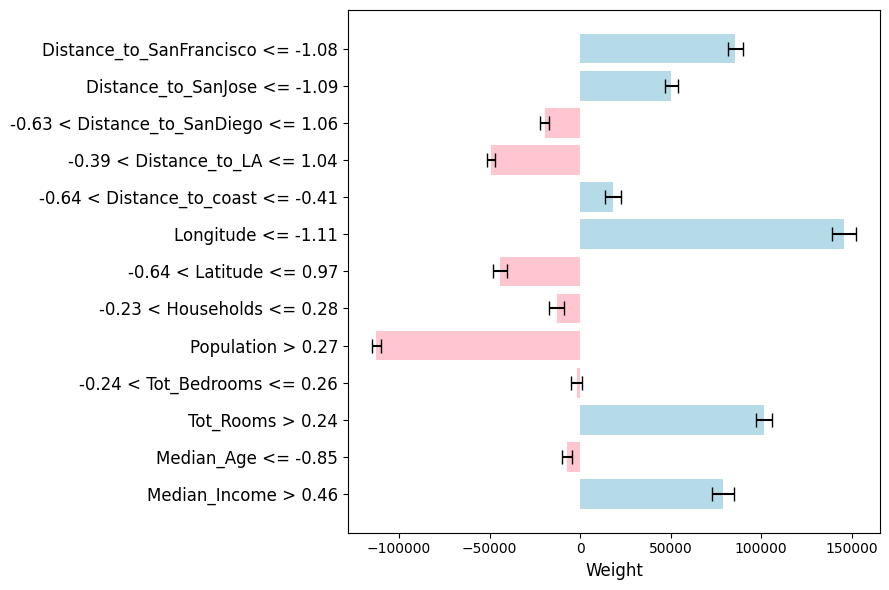

weights [79137.25809319108, -7353.96469424683, 101489.42311052166, -1967.5456862971337, -112537.45738831311, -12902.292225916193, -44281.49050838731, 145752.46816763945, 18148.123058189187, -49174.879226254816, -19612.399396951372, 50436.79026611372, 85735.0220043479] sd [6054.901239142601, 2818.5425228251625, 4356.517874065062, 2844.893039009377, 2403.6988643209056, 4014.7313573349866, 4105.87175297169, 6527.420305111705, 4425.585522761832, 2230.609135579978, 2545.192905039164, 3752.269065522987, 4199.581394678866]


In [279]:
features = list(updated_feature_stats.keys())
mean_weights = [updated_feature_stats[feature]['mean'] for feature in features]
std_weights = [updated_feature_stats[feature]['std'] for feature in features]

colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights]

feature_ids = range(len(mean_weights))
plt.figure(figsize=(9, 6))
plt.barh(feature_ids, mean_weights, xerr=std_weights, capsize=5, alpha=0.9, color=colors)
plt.yticks(feature_ids, features, fontsize=12)
plt.xlabel("Weight", fontsize=12)
plt.tight_layout()
plt.show()

print("weights", mean_weights, "sd", std_weights)

In [266]:
def extract_weights(lime_explanations):
    # Initialize a dictionary to store weights for each feature
    weights_dict = {f'feature_{i}': [] for i in range(len(lime_explanations[0].as_list()))}
    
    for explanation in lime_explanations:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            weights_dict[feature].append(weight)
    
    return weights_dict

def compute_stats(weights_dict):
    # Compute the mean and standard deviation for each feature
    stats = {}
    for feature, weights in weights_dict.items():
        mean_weight = np.mean(weights)
        std_weight = np.std(weights)
        stats[feature] = {'mean': mean_weight, 'std': std_weight}
    return stats
weights_dict = extract_weights(lime_ins1)
stats = compute_stats(weights_dict)

KeyError: 'feature_0 > 0.46'

In [177]:
shap_explain = model.explain_shap(instance, X_train_scaled)

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 321us/step


2024-06-23 14:56:37,695 - WARNING - Using 16512 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


2024-06-23 14:56:40,782 - INFO - num_full_subsets = 3
2024-06-23 14:56:40,786 - INFO - remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
2024-06-23 14:56:40,787 - INFO - num_paired_subset_sizes = 6
2024-06-23 14:56:41,063 - INFO - weight_left = 0.32084025993652715


1070184/1070184 ━━━━━━━━━━━━━━━━━━━━ 311s 290us/step


2024-06-23 15:05:22,905 - INFO - phi = array([  7717.709775  ,  20208.84664572,   4949.06369077,  16844.51214982,
        11087.27598181,  11780.84785197, -29065.27998875,  34090.19597649,
        29986.35168507, -75818.35166671, -13962.81910891,  55923.85056218,
        42085.38158036])


In [178]:
print(shap_explain)

[[  7717.709775  ]
 [ 20208.84664572]
 [  4949.06369077]
 [ 16844.51214982]
 [ 11087.27598181]
 [ 11780.84785197]
 [-29065.27998875]
 [ 34090.19597649]
 [ 29986.35168507]
 [-75818.35166671]
 [-13962.81910891]
 [ 55923.85056218]
 [ 42085.38158036]]
